In [108]:
import warnings                                  # `do not disturb` mode
warnings.filterwarnings('ignore')
import dataframe_image as dfi                  # for saving tables as images
from dateutil.relativedelta import relativedelta # working with dates with style
import hvplot as hv
import hvplot.pandas
from itertools import product                    # some useful functions
import io
import matplotlib.pyplot as plt                  # plots
import numpy as np                               # vectors and matrices
import pandas as pd                              # tables and data manipulations
from pathlib import Path
import pickle
from pypalettes import load_cmap, add_cmap
import seaborn as sns                            # more plots
from scipy import stats 
from scipy.optimize import minimize              # for function minimization
import scipy.stats as scs
from sklearn.metrics import mean_absolute_percentage_error as mape
import statsmodels.api as sm
import statsmodels.formula.api                     # statistics and econometrics
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.eval_measures import rmspe, rmse
from statsmodels.tsa.api import (kpss, adfuller, seasonal_decompose, STL)
import statsmodels.tsa.api as smt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tqdm


# Set plot styles
plt.rcParams["figure.figsize"] = [30, 5]
plt.style.use('default')


# Festlegen der Farben
cmap = load_cmap("Apricot")
colors = ['#D72000FF', '#EE6100FF', '#FFAD0AFF', '#1BB6AFFF', 
          '#9093A2FF', '#132157FF']
cmap_continuous = add_cmap(
    colors=["#FFFFFFFF", "#FFF9A1FF", "#BAD09DFF", "#76D3CFFF", "#459E9EFF", "#306677FF", "#24385FFF", "#132157FF"],
    name="apricot_continuous",
    cmap_type="continuous"
)
cmap8 = add_cmap(
    colors=['#D72000FF', '#EE6100FF', '#FFAD0AFF', '#FFD700FF', '#1BB6AFFF', '#005F73FF', '#9093A2FF', '#132157FF'],
    name="apricot8colors",
    cmap_type="discrete"
)
cmap7 = add_cmap(
    colors=['#D72000FF', '#EE6100FF', '#FFAD0AFF', '#FFD700FF', '#1BB6AFFF', '#9093A2FF', '#132157FF'],
    name="apricot7colors",
    cmap_type="discrete"
)


%matplotlib inline

In [15]:
path = "C:/Users/ChiaraVogt/Desktop/Masterarbeit/HotlineDemandPrediction_Ligue180/"

df_hourly = pd.read_csv(path + 'df_hourly_2020.csv', usecols= ['date', 'calls', 'days_to_holiday'])
df_hourly_test = pd.read_csv(path + 'df_hourly_2024.csv', usecols= ['date', 'calls', 'days_to_holiday'])

df_hourly["date"] = pd.to_datetime(df_hourly["date"])  # Falls noch nicht im Datetime-Format
df_hourly = df_hourly.set_index("date")  # Datum als Index setzen
df_hourly["weekday"] = df_hourly.index.dayofweek  # Montag=0, Sonntag=6

df_hourly_test["date"] = pd.to_datetime(df_hourly_test["date"])  # Falls noch nicht im Datetime-Format
df_hourly_test = df_hourly_test.set_index("date")  # Datum als Index setzen
df_hourly_test["weekday"] = df_hourly_test.index.dayofweek  # Montag=0, Sonntag=6

In [16]:
# Sicherstellen, dass der Index von df_hourly ein DatetimeIndex ist
df_hourly.index = pd.to_datetime(df_hourly.index)

# Slice des DataFrames ab dem Index Juli 2020
df_hourly_time_modified = df_hourly[df_hourly.index >= '2022-01-01']

# Index sicherstellen
df_hourly_time_modified['calls'] = df_hourly_time_modified['calls'].asfreq('h')

In [ ]:
df_hourly['hour'] = df_hourly.index.hour                  # Stunde
df_hourly['weekday'] = df_hourly.index.weekday            # Wochentag (0=Montag, 6=Sonntag)
df_hourly['weekofyear'] = df_hourly.index.isocalendar().week  # Woche des Jahres
df_hourly['day'] = df_hourly.index.day                    # Tag des Monats
df_hourly['month'] = df_hourly.index.month                # Monat
df_hourly['year'] = df_hourly.index.year                  # Jahr

# Deskriptive Statistik

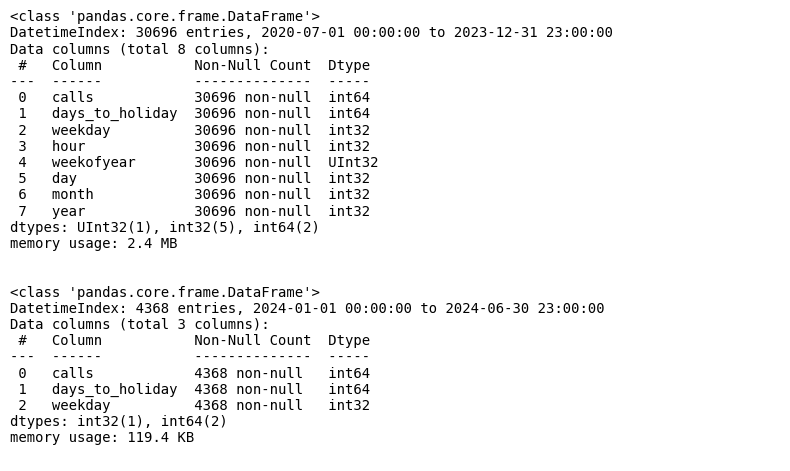

In [130]:
# beide .info() als Bild speichern
# String sammeln
buffer = io.StringIO()
df_hourly.info(buf=buffer)
buffer.write("\n\n")
df_hourly_test.info(buf=buffer)

text = buffer.getvalue()

# Matplotlib-Plot
plt.figure(figsize=(8, 4)
)
plt.text(0, 1, text, fontsize=10, family='monospace', va='top')
plt.axis('off')
plt.tight_layout()
plt.savefig("df_info_output.png", dpi=300, bbox_inches='tight')
plt.show()


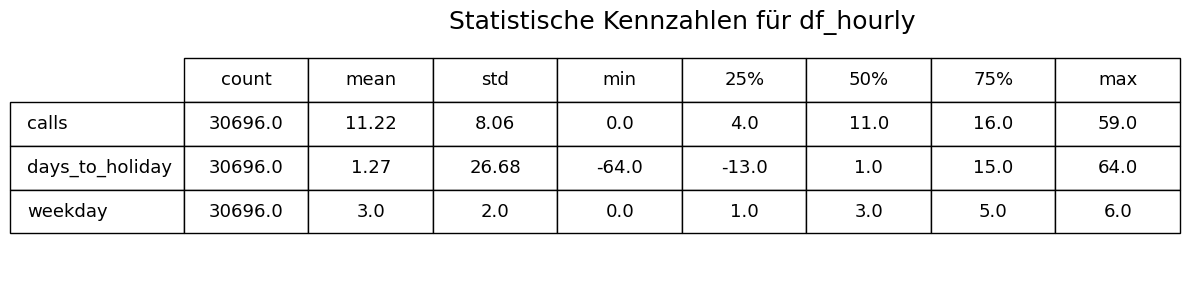

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Statistische Kennzahlen runden
desc = df_hourly.describe().T.round(2)

# Breiteres, höheres Figure-Layout
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')  # Keine Achsen anzeigen

# Titel direkt über der Tabelle
plt.text(0.5, 1.05, 'Statistische Kennzahlen für df_hourly',
         ha='center', va='bottom', fontsize=18, transform=ax.transAxes)

# Tabelle oben im Plot (z.B. y=0.6 ist relativ zu Plot-Höhe)
table = ax.table(
    cellText=desc.values,
    colLabels=desc.columns,
    rowLabels=desc.index,
    loc='upper center',
    cellLoc='center',
    colLoc='center',
    bbox=[0, 0.2, 1, 0.75]  # [x, y, Breite, Höhe] im Achsen-Koordinatensystem
)

# Fontgröße & Skalierung
table.auto_set_font_size(False)
table.set_fontsize(13)

# Bild speichern
plt.tight_layout()
plt.savefig("df_hourly_stats_top_table.png", dpi=300)
plt.show()


## Datensatz erkunden mithilfe von hvplot
Aus: Atwan (2022): *Time Series Analysis with Python Cookbook - 2nd Edition*. Chapter 9: Exploratory Data Analysis and Diagnosis.
https://learning.oreilly.com/library/view/time-series-analysis/9781805124283/text/ch010.xhtml#how-it-works-33

In [131]:
df_hourly.hvplot(x='date', y='calls',title='Normalised Hourly Calls from 2020 to 2023', color=cmap.colors[1], width=10800, height=300)

:Curve   [date]   (calls)

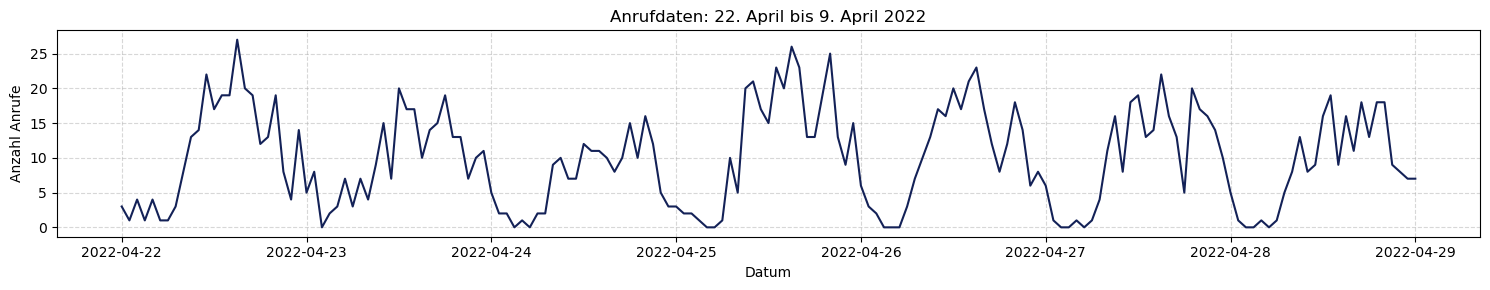

In [132]:
# Zeitraum definieren
start_date = pd.to_datetime('2022-04-22')
end_date = start_date + pd.Timedelta(days=7)

# Daten filtern
df_two_weeks = df_hourly.loc[start_date:end_date]

# Plot
plt.figure(figsize=(15, 3))
plt.plot(df_two_weeks.index, df_two_weeks['calls'], color='#132157')  # ApricotDarkBlue
plt.title('Anrufdaten: 22. April bis 9. April 2022')
plt.xlabel('Datum')
plt.ylabel('Anzahl Anrufe')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

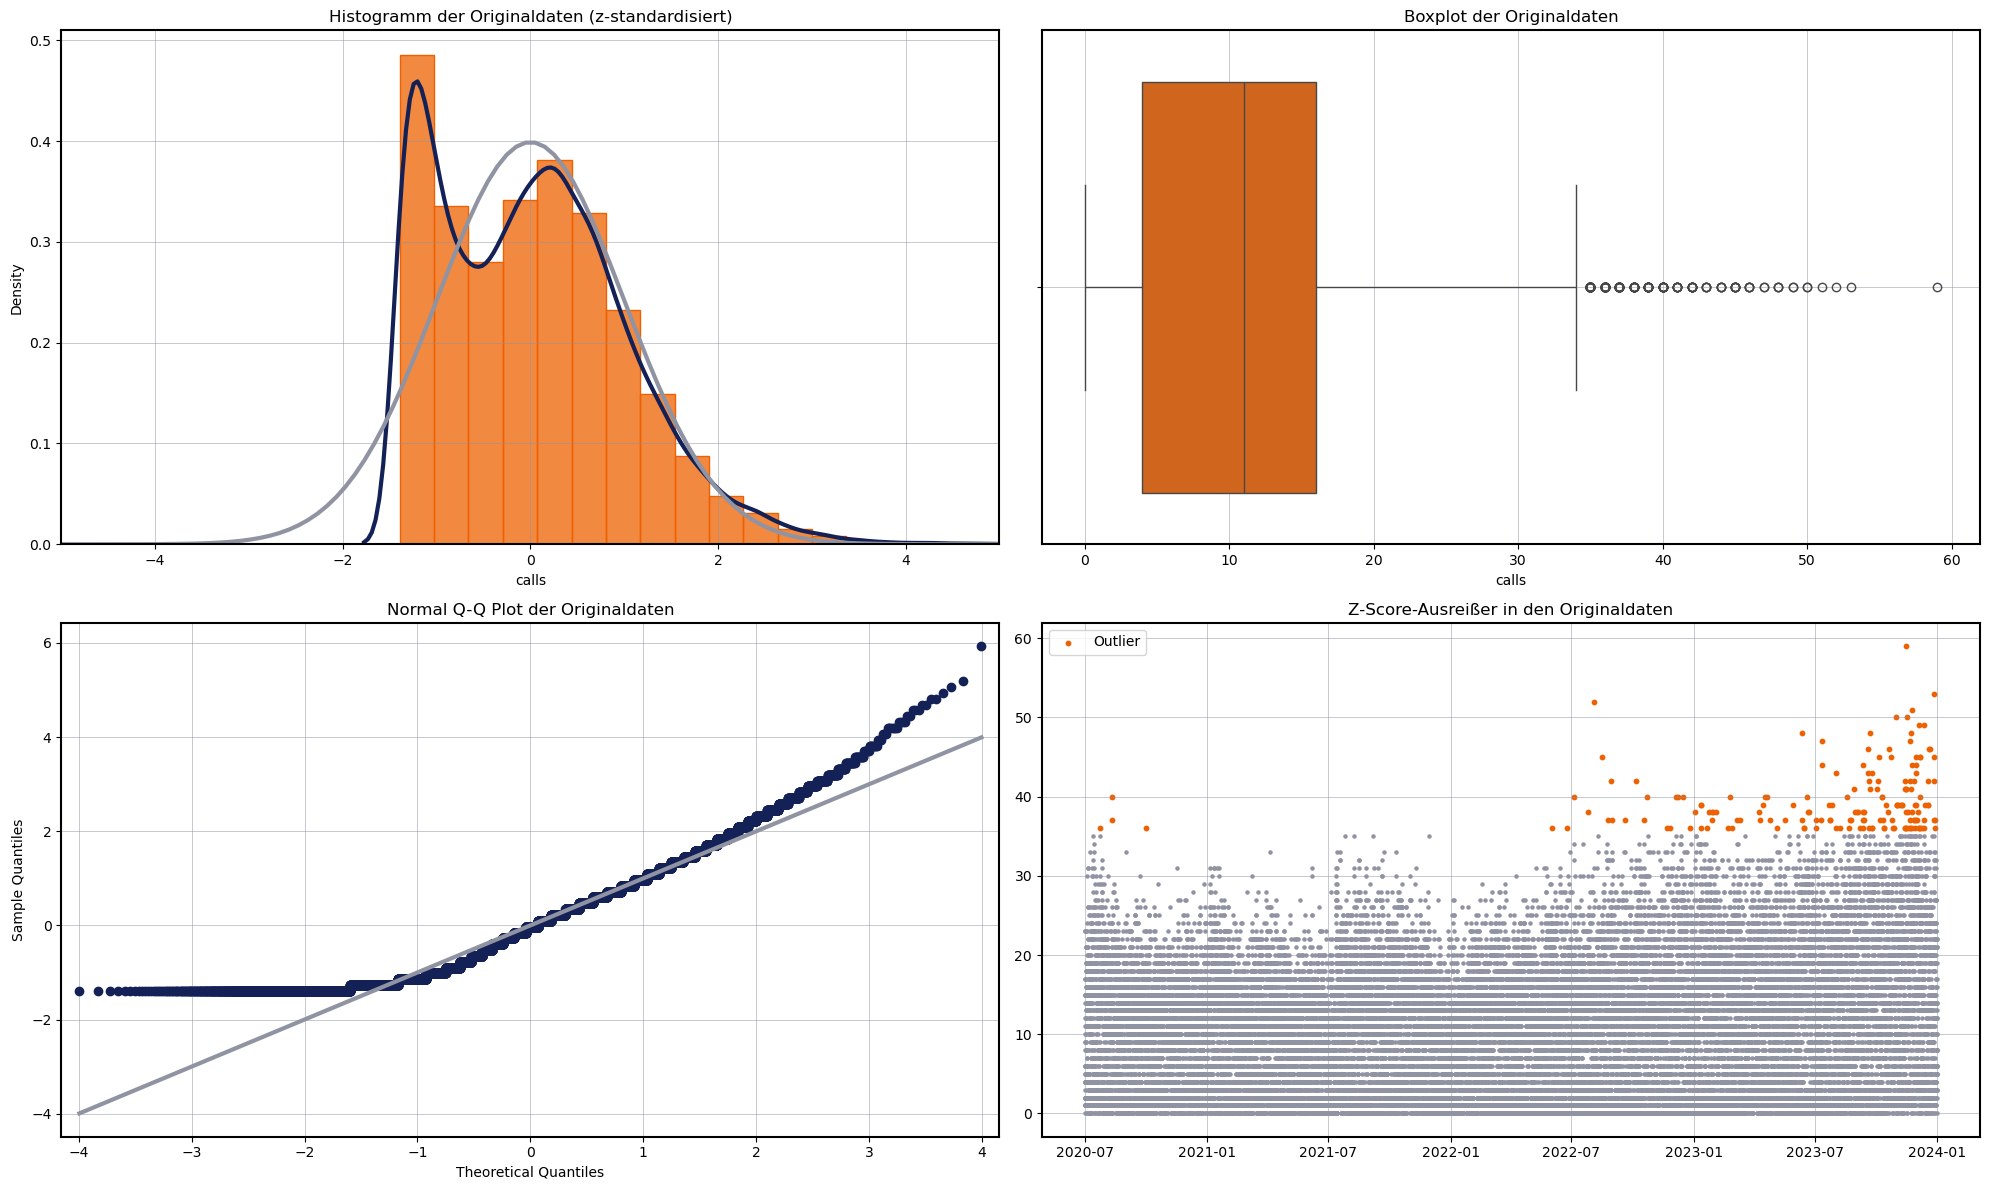

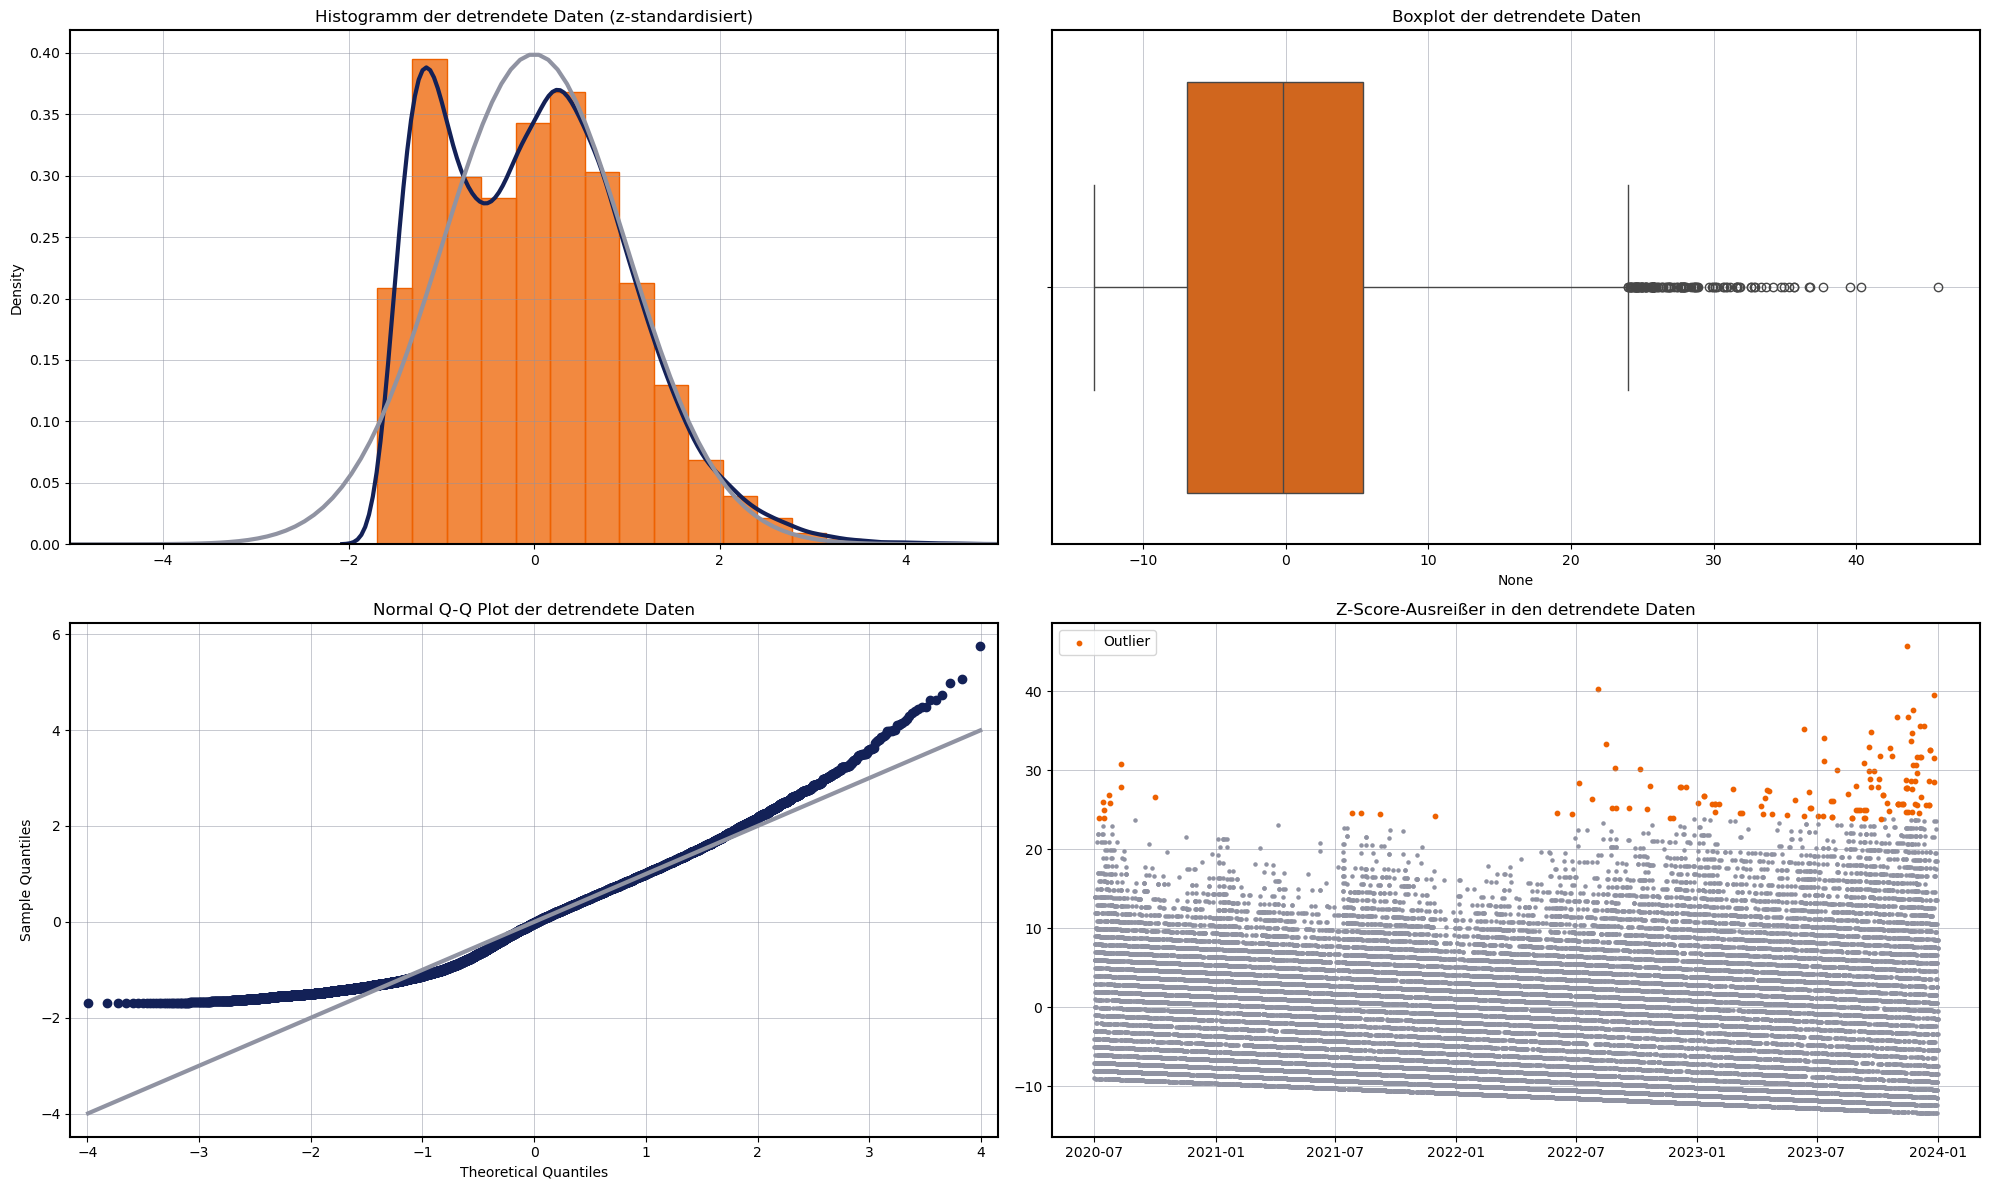

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

def plot_distribution_diagnostics(series, title_suffix="Originaldaten"):
    """
    Erzeugt 4 Plots zur Verteilungsdiagnose:
    - Histogramm mit KDE und N(0,1)
    - Boxplot
    - QQ-Plot
    - Z-Score-basierter Outlier-Plot

    Parameter:
    - series: pd.Series – Zeitreihe mit Zeitindex
    - title_suffix: str – wird an Plot-Titel angehängt
    """
    # Standardisieren
    standardized_series = (series - series.mean()) / series.std()

    # Z-Score für Outlier
    z_scores = stats.zscore(series)
    outliers = np.abs(z_scores) > 3

    background = '#ffffff'

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()

    # 1. Histogramm + KDE + N(0,1)
    sns.histplot(standardized_series, bins=20, kde=False, stat="density", ax=axes[0],
                 color=colors[1], edgecolor=colors[1])
    sns.kdeplot(standardized_series, ax=axes[0], color=colors[5], linewidth=3)
    x = np.linspace(-5, 5, 100)
    axes[0].plot(x, stats.norm.pdf(x, 0, 1), color=colors[4], linewidth=3)
    axes[0].set_xlim(-5, 5)
    axes[0].set_title(f'Histogramm der {title_suffix} (z-standardisiert)')
    axes[0].set_facecolor(background)
    axes[0].grid(color=colors[4], linestyle='-', linewidth=0.5, alpha=0.7)

    # 2. Boxplot
    sns.boxplot(x=series, ax=axes[1], color=colors[1])
    axes[1].set_title(f'Boxplot der {title_suffix}')
    axes[1].set_facecolor(background)
    axes[1].grid(color=colors[4], linestyle='-', linewidth=0.5, alpha=0.7)

    # 3. Q-Q-Plot
    sm.qqplot(standardized_series, line='s', ax=axes[2])
    axes[2].get_lines()[1].set_color(colors[4])
    axes[2].get_lines()[1].set_linewidth(3)
    axes[2].get_lines()[0].set_color(colors[5])
    axes[2].get_lines()[0].set_markerfacecolor(colors[5])
    axes[2].get_lines()[0].set_markeredgecolor(colors[5])
    axes[2].set_title(f'Normal Q-Q Plot der {title_suffix}')
    axes[2].set_facecolor(background)
    axes[2].grid(color=colors[4], linestyle='-', linewidth=0.5, alpha=0.7)

    # 4. Outlier-Plot auf Basis Z-Score
    axes[3].scatter(series.index, series, color=colors[4], s=5)
    axes[3].scatter(series.index[outliers], series[outliers], color=colors[1], s=10, label='Outlier')
    axes[3].set_title(f'Z-Score-Ausreißer in den {title_suffix}')
    axes[3].legend()
    axes[3].set_facecolor(background)
    axes[3].grid(color=colors[4], linestyle='-', linewidth=0.5, alpha=0.7)

    # Spines formatieren
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)
            spine.set_color('black')

    plt.tight_layout()
    plt.show()

# Beispielaufrufe:
# Für Originaldaten:
plot_distribution_diagnostics(df_hourly['calls'], title_suffix="Originaldaten")

# Für detrendete Daten:
from statsmodels.tsa.tsatools import detrend
detrended_calls = pd.Series(detrend(df_hourly['calls'].values), index=df_hourly.index)
plot_distribution_diagnostics(detrended_calls, title_suffix="detrendete Daten")


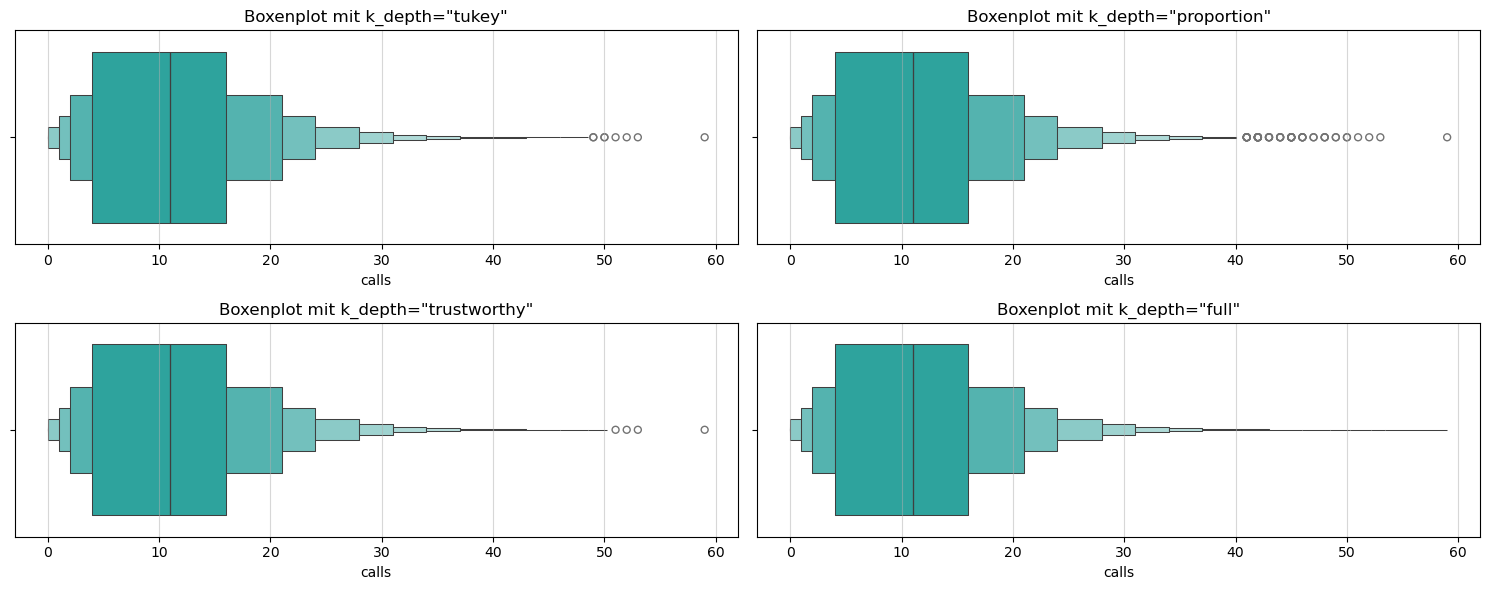

In [122]:
# Einstellungen
k_depths = ["tukey", "proportion", "trustworthy", "full"]
fig, axes = plt.subplots(2, 2, figsize=(15, 6))
axes = axes.flatten()

for i, k in enumerate(k_depths):
    sns.boxenplot(
        x=df_hourly['calls'],
        ax=axes[i],
        orient='h',
        k_depth=k,
        color=cmap.colors[3]  
        )
    axes[i].set_title(f'Boxenplot mit k_depth="{k}"')
    axes[i].grid(axis='x', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

# Grouping Dataset
## Plots der durchschnittlichen Werte der Zeitfeatures

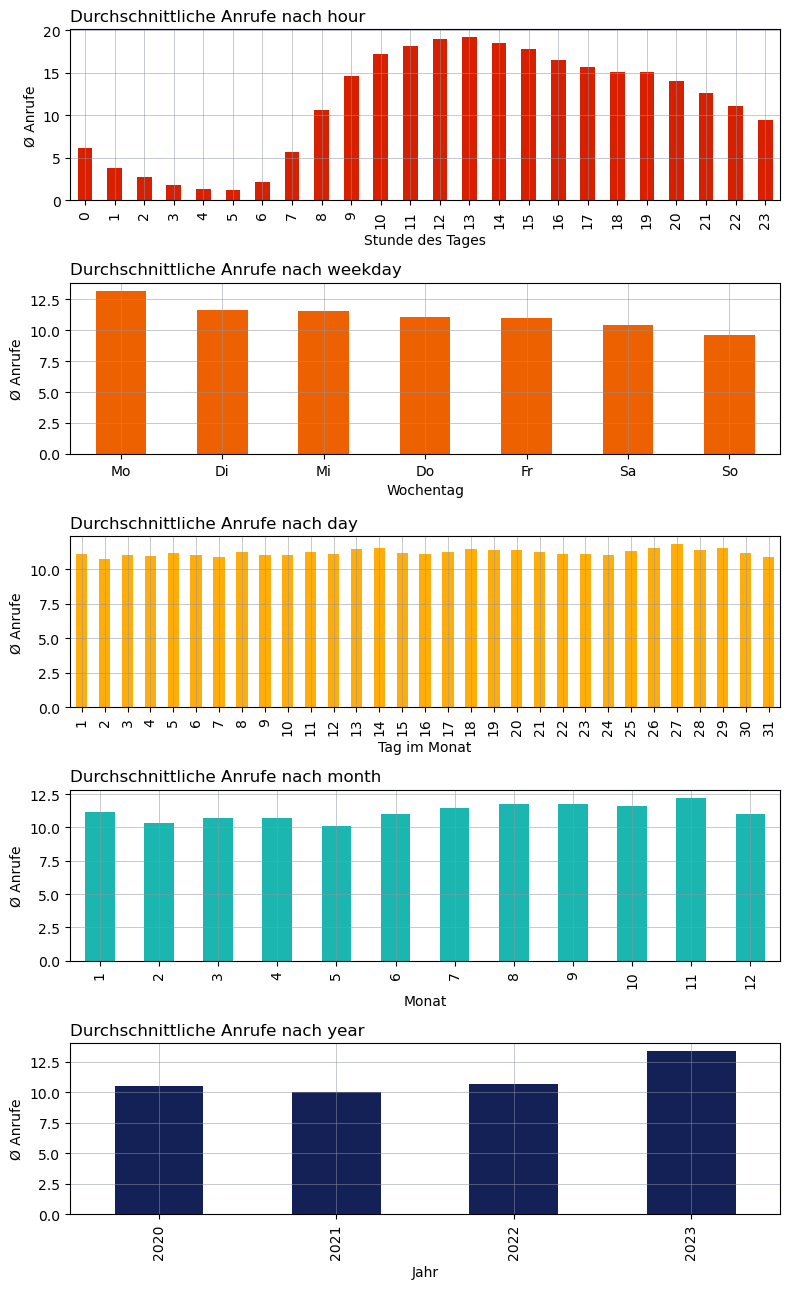

In [137]:
plot_color_keys = [0, 1, 2, 3, 5]

# Labels für Wochentage
weekday_labels = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']

# Zeitfeatures mit Beschriftung
time_features = {
    'hour':    {'xlabel': 'Stunde des Tages', 'xticks': list(range(24))},
    'weekday': {'xlabel': 'Wochentag', 'xticks': list(range(7)), 'xticklabels': weekday_labels},
    'day':     {'xlabel': 'Tag im Monat'},
    'month':   {'xlabel': 'Monat'},
    'year':    {'xlabel': 'Jahr'}
}

# Plot
plt.style.use('default')
fig, axes = plt.subplots(len(time_features), 1, figsize=(8, 13))

for idx, (ax, (feature, opts)) in enumerate(zip(axes, time_features.items())):
    grouped = df_hourly.groupby(feature)['calls'].mean().sort_index()
    color = colors[plot_color_keys[idx % len(plot_color_keys)]]
    grouped.plot(kind='bar', ax=ax, color=color)

    ax.set_title(f'Durchschnittliche Anrufe nach {feature}', fontsize=12, loc='left')
    ax.set_ylabel('Ø Anrufe')
    ax.set_xlabel(opts.get('xlabel', feature))

    if 'xticks' in opts:
        ax.set_xticks(opts['xticks'])
    if 'xticklabels' in opts:
        ax.set_xticklabels(opts['xticklabels'], rotation=0)

    ax.grid(True, color=colors[4], linestyle='-', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

# Correlation
## Zusammenhänge finden mittels kategorischer Heatmaps

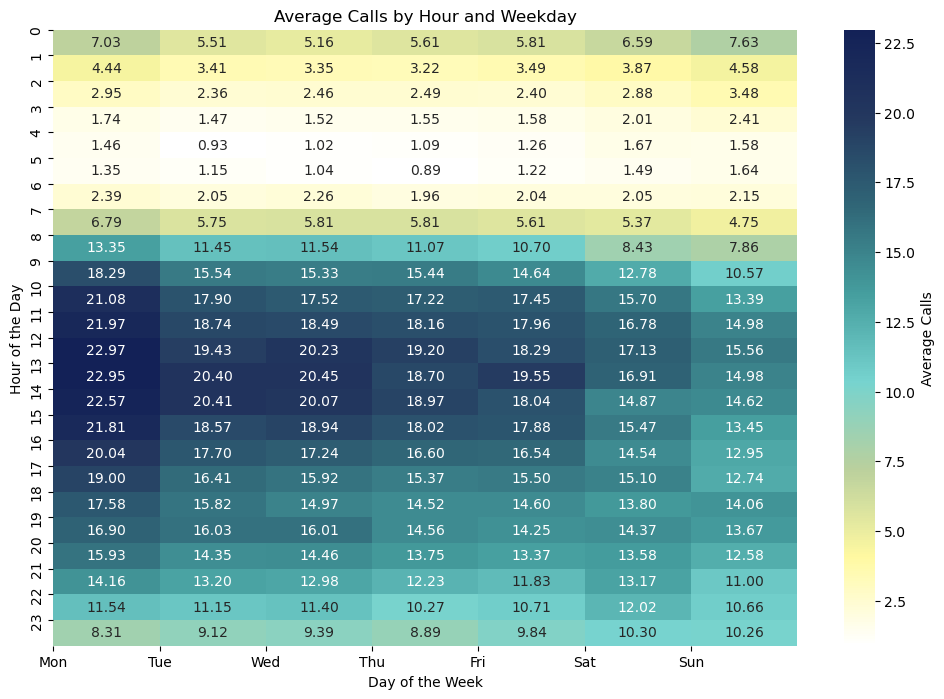

Top 5 höchste Werte:
hour  weekday
12    0          22.972527
13    0          22.945055
14    0          22.565934
11    0          21.967033
15    0          21.807692
dtype: float64

Top 5 niedrigste Werte:
hour  weekday
5     3          0.885246
4     1          0.934066
      2          1.021858
5     2          1.038251
4     3          1.092896
dtype: float64


In [84]:
avg_calls_per_hour_weekday = df_hourly.groupby(['weekday', 'hour'])['calls'].mean().unstack().T

# Plotten der Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(avg_calls_per_hour_weekday, cmap=cmap_continuous, annot=True, fmt=".2f", cbar_kws={'label': 'Average Calls'})

# Achsenbeschriftungen und Titel
plt.title('Average Calls by Hour and Weekday')
plt.ylabel('Hour of the Day')
plt.xlabel('Day of the Week')

# Anpassung der y-Achse für Wochentage und x-Achse für Stunden
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
plt.yticks(ticks=range(24), labels=range(24))

plt.show()

# Fünf höchste Werte
top_5_highest = avg_calls_per_hour_weekday.stack().nlargest(5)

# Fünf niedrigste Werte
top_5_lowest = avg_calls_per_hour_weekday.stack().nsmallest(5)

print("Top 5 höchste Werte:")
print(top_5_highest)

print("\nTop 5 niedrigste Werte:")
print(top_5_lowest)

Es ist ein starker Zusammenhang zwischen der Uhrzeit und der Menge der Anrufe zu sehen, jedoch auch die Wochentage bilden ein eindrückliches Muster bei dem die Menge an Anrufen über die Woche hinweg abnimmt. 
- Höchste Werte Montag 10 und 16 Uhr
- allgemein am stärksten mittags bis nachmittags
- kleines Cluster sonntag abends
- die Anrufe nachts werden richtung wochenende mehr
- ein weiteres kleines Cluster freitag zwischen 13 und 14 Uhr
  
  
Die nächsten Graphen zeigen die nach Häufigkeit gewichteten Anrufe an, also den Mittelwert der passenden Werte. Der erste Plot zeigt die Anrufmenge pro Stunde/Wochentag, der zweite Plot den Durchschnitt des Tageswertes zwischen Tagesdatum und Monat. Das Mittel wurde gewählt, damit Tage, die über die Jahre hinweg weniger vorkommen als andere nicht das Ergebnis verzerren.

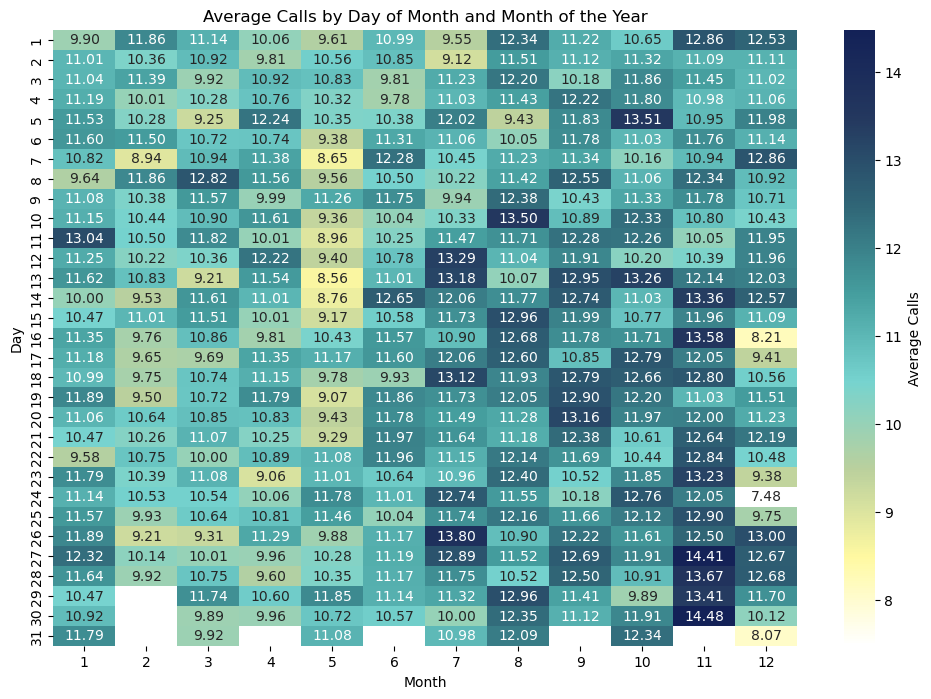

Top 5 höchste Werte:
day  month
30   11       14.479167
27   11       14.406250
26   7        13.802083
28   11       13.666667
16   11       13.583333
dtype: float64

Top 5 niedrigste Werte:
day  month
24   12       7.479167
31   12       8.072917
16   12       8.208333
13   5        8.555556
7    5        8.652778
dtype: float64


In [87]:
calls_per_day_month = df_hourly.groupby(['month', 'day'])['calls'].mean().unstack().T

# Plotten der Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(calls_per_day_month, cmap=cmap_continuous, annot=True, fmt=".2f", cbar_kws={'label': 'Average Calls'})

# Achsenbeschriftungen und Titel
plt.title('Average Calls by Day of Month and Month of the Year')
plt.xlabel('Month')
plt.ylabel('Day')

# Anpassung der y-Achse für Wochentage
plt.xticks(rotation=0)

plt.show()

# Fünf höchste Werte
top_5_highest = calls_per_day_month.stack().nlargest(5)

# Fünf niedrigste Werte
top_5_lowest = calls_per_day_month.stack().nsmallest(5)

print("Top 5 höchste Werte:")
print(top_5_highest)

print("\nTop 5 niedrigste Werte:")
print(top_5_lowest)


In der Heatmap, welche die Durchschnittsmenge der Anrufe pro Tag/Monat zeigt sind folgende beobachtungen zu treffen:
Höchste Werte: 
- Einzeltage: 29.02. (385), 09.03. (378), 14.03. (376) und 27.11. (371)
- erste Interpretation:
    - 29.02. Wert vielleicht so hoch, weil nur Werte von 2016 und 2020 zur Verfügung standen.
    - 09.03. 1 Tag nach dem feministischen Kampftag, dieser macht aufmerksam und ermutigt.
    - 14.03. Vermutung: ebenso uin Zusammenhang mit 08. März Aktionswoche
    - 27.11. zwei Tage nach dem Tag gegen patriarchale Gewalt, auch zu dieser Zeit läuft wie am 08. März eine Kampagne zu patriarchaler Gewalt
- optische Cluster: 06.03. - 24.03., 25.11. - 30.11., etwas blasser: 26.12. - 29.12.
Geringe Werte:
- 31.12. (228), 30.07. (230), 02.07. (236), 24.12. (240)
- Cluster: 01.07. - 10.07., blasser: 25.06. - 30.06., 14.07. - 23.07., 27.07. - 06.08.

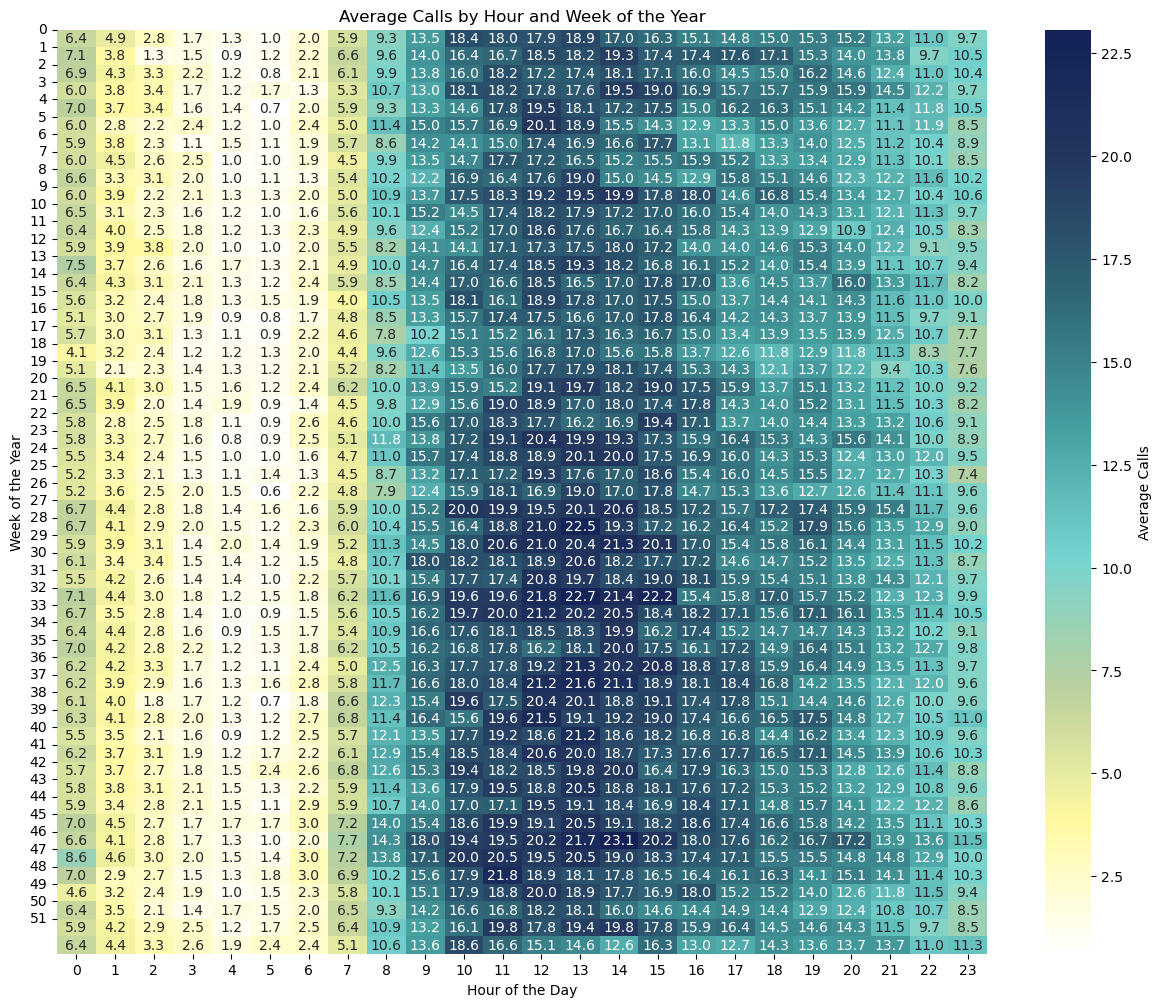

Top 5 höchste Werte:
weekofyear  hour
47          14      23.071429
33          13      22.678571
29          13      22.464286
33          15      22.178571
            12      21.821429
dtype: float64

Top 5 niedrigste Werte:
weekofyear  hour
27          5       0.615385
5           5       0.666667
39          5       0.678571
17          5       0.761905
24          4       0.761905
dtype: float64


In [88]:
avg_calls_per_hour_yearweek = df_hourly.groupby(['hour', 'weekofyear'])['calls'].mean().unstack().T

# Plotten der Heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(avg_calls_per_hour_yearweek, cmap=cmap_continuous, annot=True, fmt=".1f", cbar_kws={'label': 'Average Calls'})

# Achsenbeschriftungen und Titel
plt.title('Average Calls by Hour and Week of the Year')
plt.xlabel('Hour of the Day')
plt.ylabel('Week of the Year')

# Anpassung der y-Achse für Wochentage und x-Achse für Stunden
plt.xticks(rotation=0)
plt.yticks(ticks=range(52), labels=range(52))

plt.show()
# Fünf höchste Werte
top_5_highest = avg_calls_per_hour_yearweek.stack().nlargest(5)
# Fünf niedrigste Werte
top_5_lowest = avg_calls_per_hour_yearweek.stack().nsmallest(5)
print("Top 5 höchste Werte:")
print(top_5_highest)
print("\nTop 5 niedrigste Werte:")
print(top_5_lowest)


Fragen:
- Verschiebt sich die Anrufuhrzeit mit der Saison?
    - auf den ersten Blick lässt sich kaum eine saisonale Verschiebung erkennen 

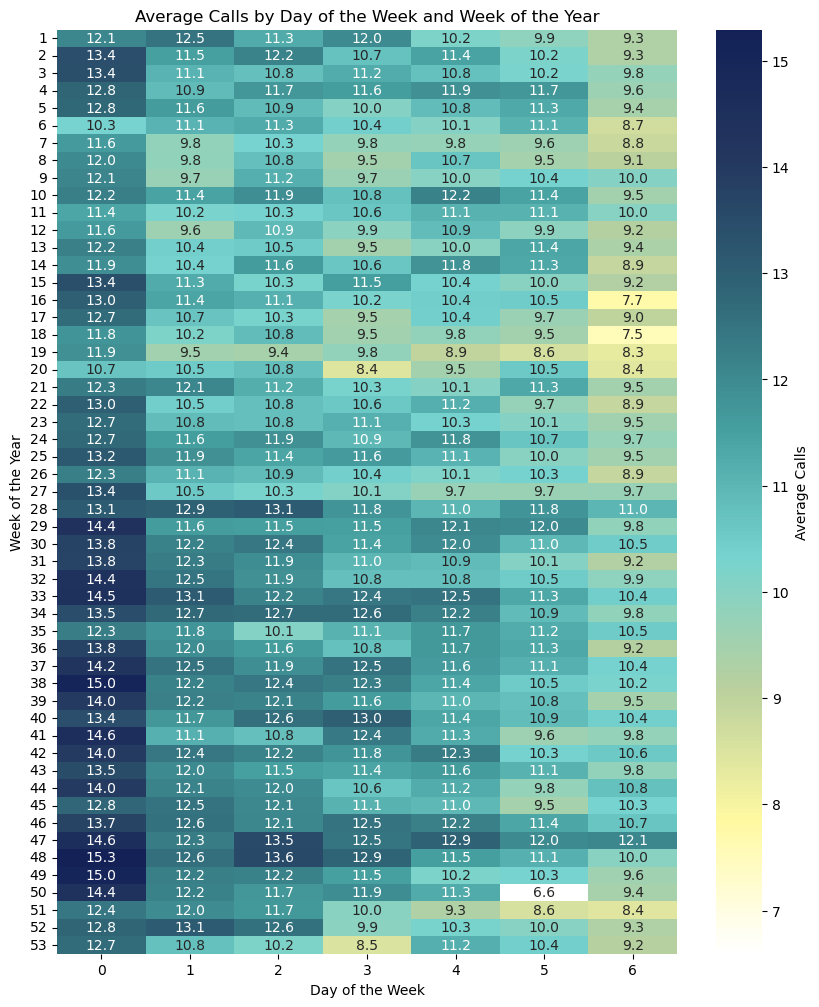

Top 5 höchste Werte:
weekofyear  weekday
48          0          15.291667
38          0          15.041667
49          0          15.031250
47          0          14.583333
41          0          14.562500
dtype: float64

Top 5 niedrigste Werte:
weekofyear  weekday
50          5          6.593750
18          6          7.541667
16          6          7.722222
19          6          8.291667
20          6          8.375000
dtype: float64


In [90]:
avg_calls_per_weekday_yearweek = df_hourly.groupby(['weekday', 'weekofyear'])['calls'].mean().unstack().T
# Plotten der Heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(avg_calls_per_weekday_yearweek, cmap=cmap_continuous, annot=True, fmt=".1f", cbar_kws={'label': 'Average Calls'})

# Achsenbeschriftungen und Titel
plt.title('Average Calls by Day of the Week and Week of the Year')
plt.xlabel('Day of the Week')
plt.ylabel('Week of the Year')

plt.show()
# Fünf höchste Werte
top_5_highest = avg_calls_per_weekday_yearweek.stack().nlargest(5)
# Fünf niedrigste Werte
top_5_lowest = avg_calls_per_weekday_yearweek.stack().nsmallest(5)
print("Top 5 höchste Werte:")
print(top_5_highest)
print("\nTop 5 niedrigste Werte:")
print(top_5_lowest)

In der Heatmap, welche die Durchschnittsmenge der Anrufe pro Jahreswoche/Wochentag zeigt sind folgende beobachtungen zu treffen:
Höchste Werte: 
- Einzeltage: Mo KW 48 (410), Mo KW 11 (404), Di KW 53 (398) und Mo KW 10 (382)
- erste Interpretation:
    - Mo KW 48 (410) Woche des 25.11. (Tag gegen patriarchale Gewalt) und ein Montag noch dazu
    - Mo KW 11 (404) Woche des 08.03. (feministischen Kampftag) und ein Montag
    - Di KW 53 (398) zwischen Weihnachten und Silvester
    - Mo KW 10 (382) Zeitraum 08.03. und Montag
- optische Cluster: KW 10 und 11 und darum die Montage, Montage in KW 47 -51 + KW 47 und 48, etwas blasser: Montage KW 32 - 39
Geringe Werte:
- Sa und So allgemein
- insbesondere in KW 26, 27, 29, 30, 31, 44, 19

## Prüfen der Peaks der einzelnen Heatmaps
### Für Monatstage/Monat

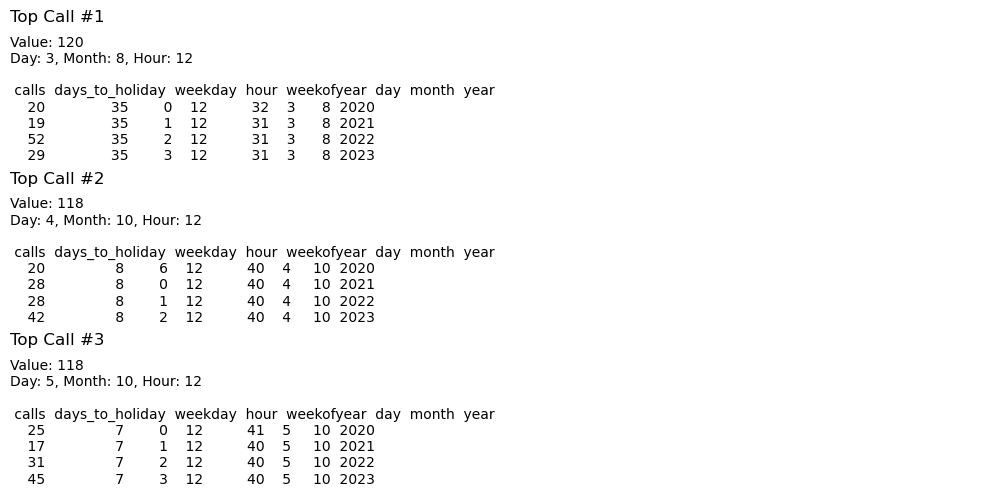

In [103]:
# Pivot-Tabelle: calls_per_hour_day_month
calls_per_hour_day_month = df_hourly.pivot_table(values='calls',
    index=['day','month'], columns='hour', aggfunc='sum')

# Top-3 Werte
top_3_values = calls_per_hour_day_month.stack().nlargest(3)

# Ergebnisse sammeln
results = []
for (day, month, hour), value in top_3_values.items():
    matches = df_hourly[
        (df_hourly['month']==month)&
        (df_hourly['day']==day)&
        (df_hourly['hour']==hour)
    ]
    results.append((value, day, month, hour, matches))

# Plot: 3 Zeilen, 1 Spalte
fig, axes = plt.subplots(3, 1, figsize=(10, 5))

for ax, (value, day, month, hour, matches) in zip(axes, sorted(results, key=lambda x: -x[0])):
    title = f"Top Call #{results.index((value, day, month, hour, matches))+1}"
    ax.set_title(title, loc='left')  # Titel linksbündig
    # Text links oben unterhalb des Titels
    text = (
        f"Value: {value}\n"
        f"Day: {day}, Month: {month}, Hour: {hour}\n\n"
        f"{matches.to_string(index=False)}"
    )
    ax.text(
        0, 0.95, text,
        ha='left', va='top',
        transform=ax.transAxes,
        fontsize=10
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

## Korrelationen der Features mit calls

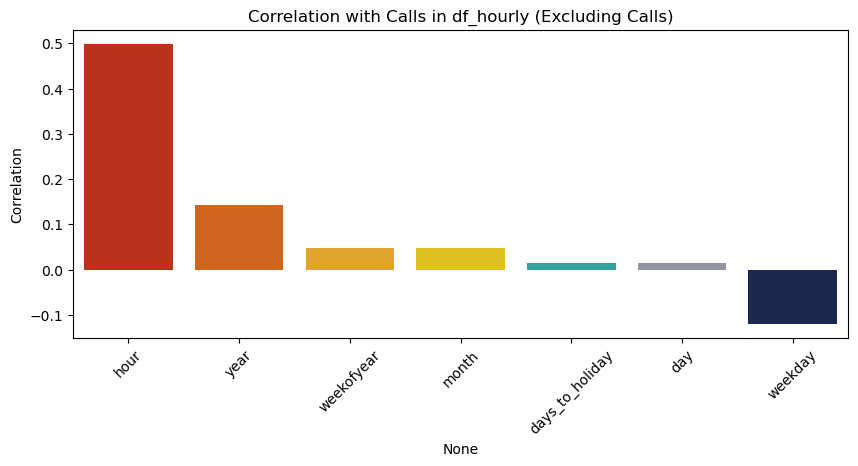

In [139]:
# Korrelationen in Bezug auf 'calls' für df_hourly (ohne 'calls' selbst)
plt.figure(figsize=(10, 4))
correlation_hourly = df_hourly.corr()['calls'].drop('calls').sort_values(ascending=False)
sns.barplot(x=correlation_hourly.index, y=correlation_hourly.values, palette="apricot7colors")
plt.title('Correlation with Calls in df_hourly (Excluding Calls)')
plt.xticks(rotation=45)
plt.ylabel('Correlation')
plt.show()

## Dekomposition der Zeitreihe


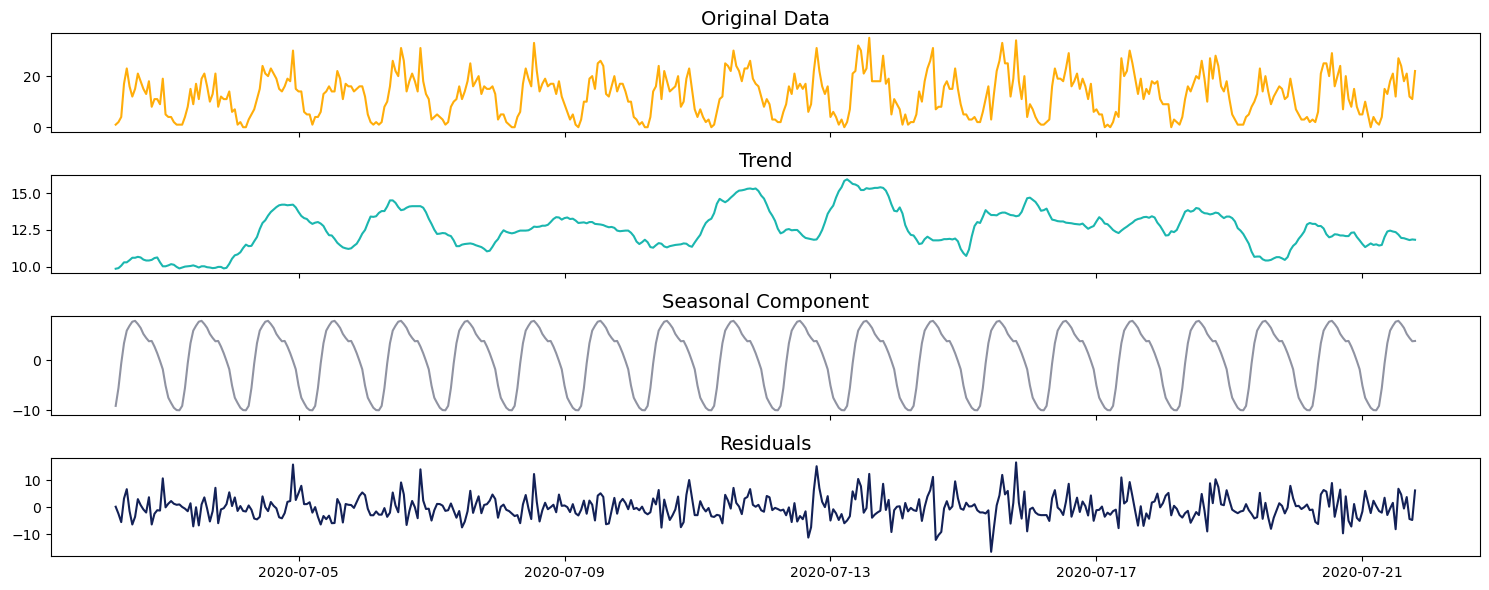

In [133]:

# Zeitreihe vorbereiten
df_hourly = df_hourly.sort_index()  # Falls nicht bereits sortiert
calls_series = df_hourly['calls'].asfreq('h')  # Sicherstellen, dass es wirklich stündlich ist

# Dekomposition (z. B. mit wöchentlicher Periode)
hourly_decomposed = seasonal_decompose(calls_series, model='additive', period=24)

# Danach kannst du wie gehabt deinen Plot-Code verwenden:
fig, axes = plt.subplots(4, 1, figsize=(15, 6), sharex=True)

axes[0].plot(calls_series[30:500], color=colors[2])
axes[0].set_title('Original Data', fontsize=14)

axes[1].plot(hourly_decomposed.trend[30:500], color=colors[3])
axes[1].set_title('Trend', fontsize=14)

axes[2].plot(hourly_decomposed.seasonal[30:500], color=colors[4])
axes[2].set_title('Seasonal Component', fontsize=14)

axes[3].plot(hourly_decomposed.resid[30:500], color=colors[5])
axes[3].set_title('Residuals', fontsize=14)

plt.tight_layout()
plt.show()

## Stationarität prüfen

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

def print_results(output, test='adf'):   
    pval = output[1]
    test_score = output[0]
    lags = output[2]   
    decision = 'Non-Stationary'
    if test == 'adf':
        critical = output[4]
        if pval < 0.05:
            decision = 'Stationary'
    elif test == 'kpss':
        critical = output[3]
        if pval >= 0.05:
            decision = 'Stationary'           
    output_dict = {
        'Test Statistic': test_score,
        'p-value': pval,
        'Number of lags': lags,
        'Decision': decision
    }
    for key, value in critical.items():
        output_dict["Critical Value (%s)" % key] = value
      
    return pd.Series(output_dict, name=test)

# ADF- und KPSS-Test für df_hourly
hourly_adf_output = adfuller(df_hourly['calls'])
hourly_kpss_output = kpss(df_hourly['calls'])

hourly_results = pd.concat([
    print_results(hourly_adf_output, 'adf'),
    print_results(hourly_kpss_output, 'kpss')
], axis=1)

# Überprüfe die Struktur von hourly_results, um sicherzustellen, dass die Spalten korrekt sind
print(hourly_results)


                              adf            kpss
Test Statistic          -11.34717       36.149446
p-value                       0.0            0.01
Number of lags                 51               2
Decision               Stationary  Non-Stationary
Critical Value (1%)     -3.430563           0.739
Critical Value (5%)     -2.861634           0.463
Critical Value (10%)     -2.56682           0.347
Critical Value (2.5%)         NaN           0.574


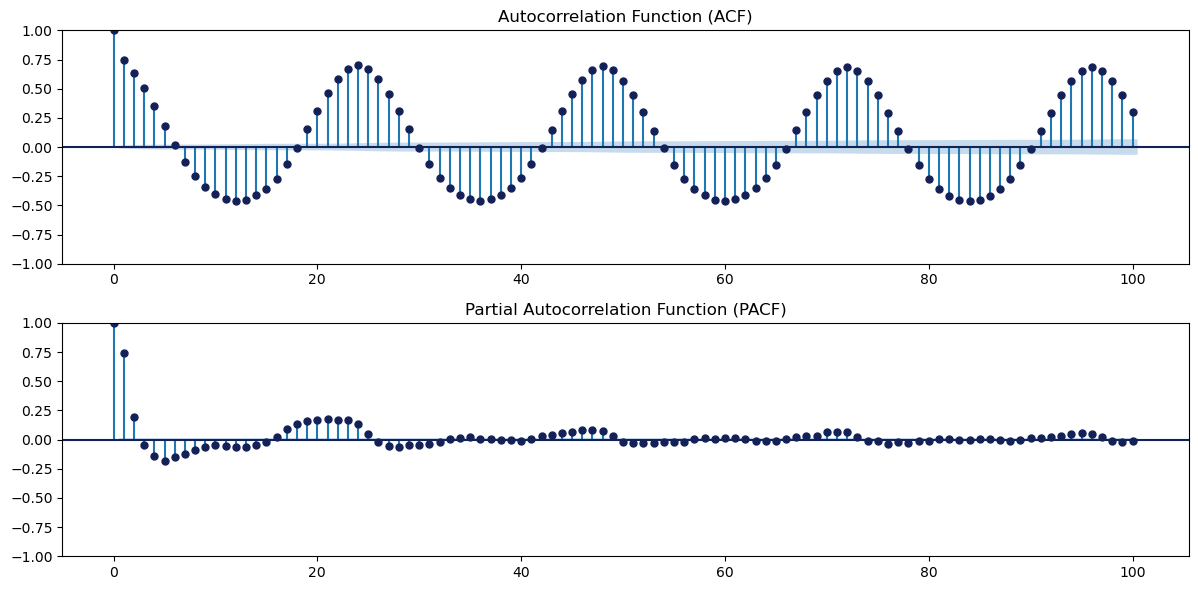

In [134]:
## Prüfung von Autokorrelation

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF- und PACF-Plots für die Originaldaten (z. B. bis Lag 100)
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# ACF
plot_acf(df_hourly['calls'], ax=axes[0], lags=100, color=colors[5])
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF
plot_pacf(df_hourly['calls'], ax=axes[1], lags=100, method='ywm', color=colors[5])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()
